In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv("Heart_disease_statlog.csv")

In [3]:
df.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,70,1,3,130,322,0,2,109,0,2.4,1,3,1,1
1,67,0,2,115,564,0,2,160,0,1.6,1,0,3,0
2,57,1,1,124,261,0,0,141,0,0.3,0,0,3,1
3,64,1,3,128,263,0,0,105,1,0.2,1,1,3,0
4,74,0,1,120,269,0,2,121,1,0.2,0,1,1,0


In [4]:
df.shape

(270, 14)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       270 non-null    int64  
 1   sex       270 non-null    int64  
 2   cp        270 non-null    int64  
 3   trestbps  270 non-null    int64  
 4   chol      270 non-null    int64  
 5   fbs       270 non-null    int64  
 6   restecg   270 non-null    int64  
 7   thalach   270 non-null    int64  
 8   exang     270 non-null    int64  
 9   oldpeak   270 non-null    float64
 10  slope     270 non-null    int64  
 11  ca        270 non-null    int64  
 12  thal      270 non-null    int64  
 13  target    270 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 29.7 KB


In [6]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df = df.rename(columns={
    "age": "Idade",
    "sex": "Sexo",
    "cp": "Tipo de dor",
    "trestbps": "Pressão",
    "chol": "Colesterol",
    "fbs": "Glicemia alta",
    "restecg": "ECG repouso",
    "thalach": "Freq. máxima",
    "exang": "Angina exercício",
    "oldpeak": "Oldpeak",
    "slope": "Inclinação ST",
    "ca": "Vasos",
    "thal": "Cintilografia",
    "target": "Doença",
})

In [9]:
df["Sexo"] = df["Sexo"].map({0: "Feminino", 1: "Masculino"})
df["Glicemia alta"] = df["Glicemia alta"].map({0: "Não", 1: "Sim"})
df["Angina exercício"] = df["Angina exercício"].map({0: "Não", 1: "Sim"})

In [10]:
df["Tipo de dor"] = df["Tipo de dor"].map({
    0: "Angina típica",
    1: "Angina atípica",
    2: "Dor não anginosa",
    3: "Assintomático",
})

In [11]:
df["ECG repouso"] = df["ECG repouso"].map({
    0: "Normal",
    1: "Anormalidade ST-T",
    2: "Hipertrofia ventricular",
})

In [12]:
df["Inclinação ST"] = df["Inclinação ST"].map({0: "Ascendente", 1: "Plano", 2: "Descendente"})
df["Cintilografia"] = df["Cintilografia"].map({1: "Normal", 2: "Defeito fixo", 3: "Defeito reversível"})
df["Vasos"] = df["Vasos"].astype(str)

In [13]:
df["Doença (0/1)"] = df["Doença"]
df["Doença"] = df["Doença"].map({0: "Ausente", 1: "Presente"})

In [14]:
df["Faixa etária"] = pd.cut(
    df["Idade"],
    bins=[20, 40, 50, 60, 70, 80],
    labels=["20-39", "40-49", "50-59", "60-69", "70-79"],
    right=False,
).astype(str)

In [15]:
numericas = ["Idade", "Pressão", "Colesterol", "Freq. máxima", "Oldpeak"]
categoricas = ["Sexo", "Tipo de dor", "Glicemia alta", "ECG repouso", "Angina exercício",
               "Inclinação ST", "Vasos", "Cintilografia", "Faixa etária"]

In [16]:
df["Atípico"] = False
for coluna in numericas:
    q1 = df[coluna].quantile(0.25)
    q3 = df[coluna].quantile(0.75)
    iqr = q3 - q1
    atipico_coluna = (df[coluna] < q1 - 1.5 * iqr) | (df[coluna] > q3 + 1.5 * iqr)
    print(coluna, atipico_coluna.sum())
    df["Atípico"] = df["Atípico"] | atipico_coluna

Idade 0
Pressão 9
Colesterol 5
Freq. máxima 1
Oldpeak 4


In [17]:
df["Atípico"].sum()

np.int64(18)

In [18]:
df[df["Atípico"]]

,Idade,Sexo,Tipo de dor,Pressão,Colesterol,Glicemia alta,ECG repouso,Freq. máxima,Angina exercício,Oldpeak,Inclinação ST,Vasos,Cintilografia,Doença,Doença (0/1),Faixa etária,Atípico
1,67,Feminino,Dor não anginosa,115,564,Não,Hipertrofia ventricular,160,Não,1.6,Plano,0,Defeito reversível,Ausente,0,60-69,True
9,63,Feminino,Assintomático,150,407,Não,Hipertrofia ventricular,154,Não,4.0,Plano,3,Defeito reversível,Presente,1,60-69,True
52,65,Feminino,Dor não anginosa,140,417,Sim,Hipertrofia ventricular,157,Não,0.8,Ascendente,1,Normal,Ausente,0,60-69,True
58,59,Feminino,Assintomático,174,249,Não,Normal,143,Sim,0.0,Plano,0,Normal,Presente,1,50-59,True
87,59,Masculino,Angina típica,178,270,Não,Hipertrofia ventricular,145,Não,4.2,Descendente,0,Defeito reversível,Ausente,0,50-59,True
101,67,Masculino,Assintomático,120,237,Não,Normal,71,Não,1.0,Plano,0,Normal,Presente,1,60-69,True
110,55,Feminino,Assintomático,180,327,Não,Anormalidade ST-T,117,Sim,3.4,Plano,0,Normal,Presente,1,50-59,True
117,56,Feminino,Assintomático,200,288,Sim,Hipertrofia ventricular,133,Sim,4.0,Descendente,2,Defeito reversível,Presente,1,50-59,True
144,54,Masculino,Angina atípica,192,283,Não,Hipertrofia ventricular,195,Não,0.0,Ascendente,1,Defeito reversível,Presente,1,50-59,True
156,55,Masculino,Assintomático,140,217,Não,Normal,111,Sim,5.6,Descendente,0,Defeito reversível,Presente,1,50-59,True


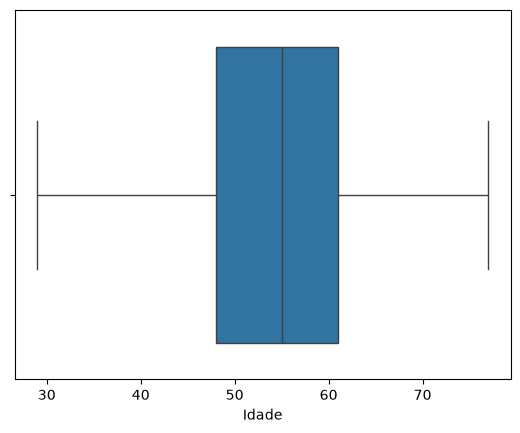

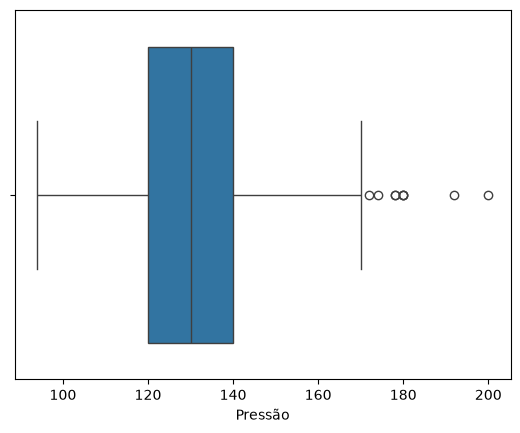

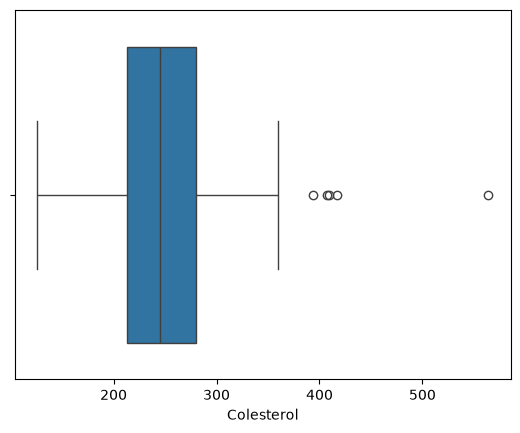

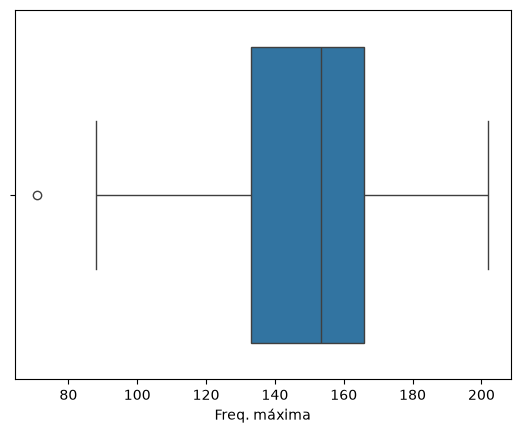

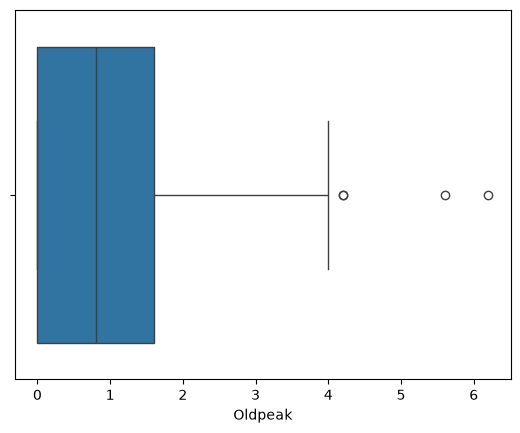

In [19]:
for coluna in numericas:
    sns.boxplot(data=df, x=coluna)
    plt.show()

In [20]:
sem_atipicos = df[~df["Atípico"]]

In [21]:
df[numericas].agg(["mean", "std"])

,Idade,Pressão,Colesterol,Freq. máxima,Oldpeak
mean,54.433333,131.344444,249.659259,149.677778,1.05000
std,9.109067,17.861608,51.686237,23.165717,1.14521


In [22]:
sem_atipicos[numericas].agg(["mean", "std"])

,Idade,Pressão,Colesterol,Freq. máxima,Oldpeak
mean,54.031746,129.325397,245.468254,150.087302,0.961508
std,9.188106,15.409589,44.058217,22.909668,1.009510


In [23]:
df[numericas].corrwith(df["Doença (0/1)"])

Idade           0.212322
Pressão         0.155383
Colesterol      0.118021
Freq. máxima   -0.418514
Oldpeak         0.417967
dtype: float64

In [24]:
sem_atipicos[numericas].corrwith(sem_atipicos["Doença (0/1)"])

Idade           0.212996
Pressão         0.113593
Colesterol      0.161290
Freq. máxima   -0.421707
Oldpeak         0.424671
dtype: float64

In [25]:
df["Doença"].value_counts()

Doença
Ausente     150
Presente    120
Name: count, dtype: int64

In [26]:
df["Doença"].value_counts(normalize=True)

Doença
Ausente     0.555556
Presente    0.444444
Name: proportion, dtype: float64

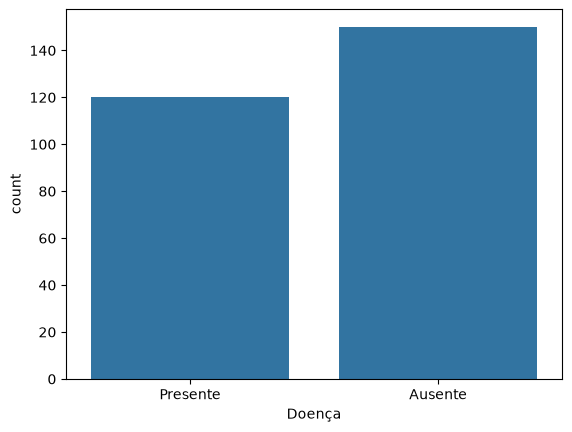

In [27]:
sns.countplot(data=df, x="Doença")
plt.show()

In [28]:
for coluna in categoricas:
    print(df[coluna].value_counts().sort_index())
    print()

Sexo
Feminino      87
Masculino    183
Name: count, dtype: int64

Tipo de dor
Angina atípica       42
Angina típica        20
Assintomático       129
Dor não anginosa     79
Name: count, dtype: int64

Glicemia alta
Não    230
Sim     40
Name: count, dtype: int64

ECG repouso
Anormalidade ST-T            2
Hipertrofia ventricular    137
Normal                     131
Name: count, dtype: int64

Angina exercício
Não    181
Sim     89
Name: count, dtype: int64

Inclinação ST
Ascendente     130
Descendente     18
Plano          122
Name: count, dtype: int64

Vasos
0    160
1     58
2     33
3     19
Name: count, dtype: int64

Cintilografia
Defeito fixo           14
Defeito reversível    104
Normal                152
Name: count, dtype: int64

Faixa etária
20-39     12
40-49     67
50-59    107
60-69     74
70-79     10
Name: count, dtype: int64



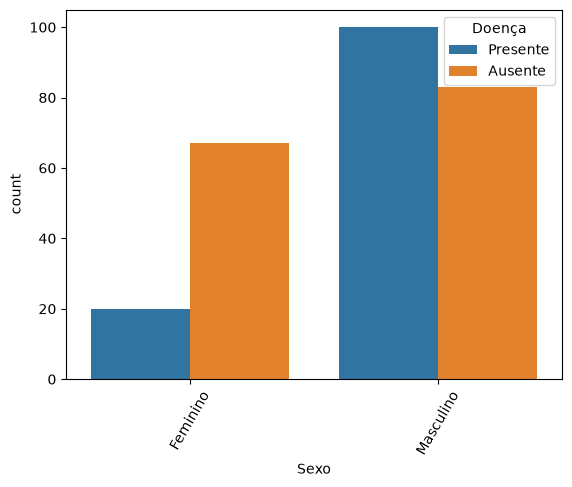

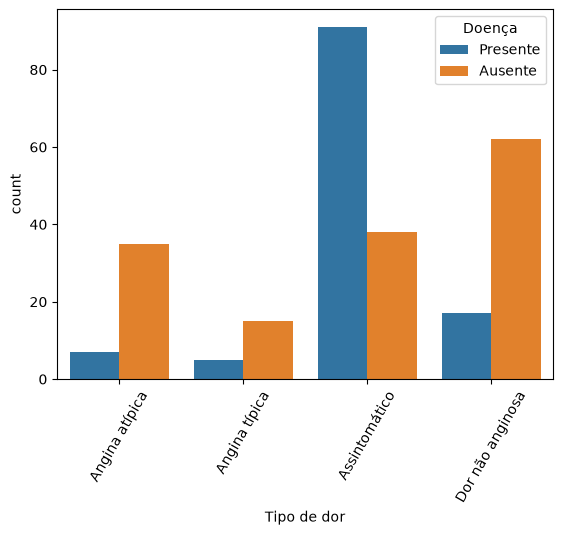

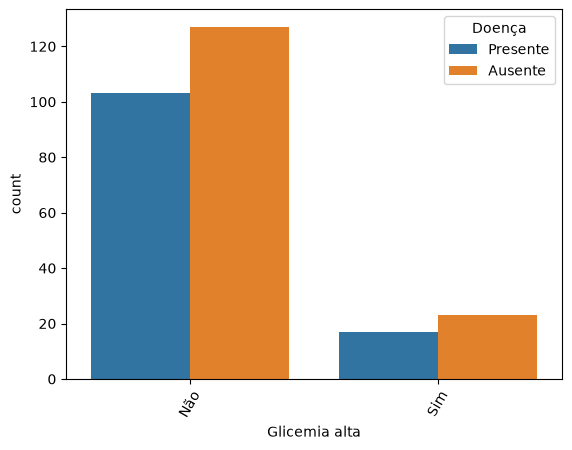

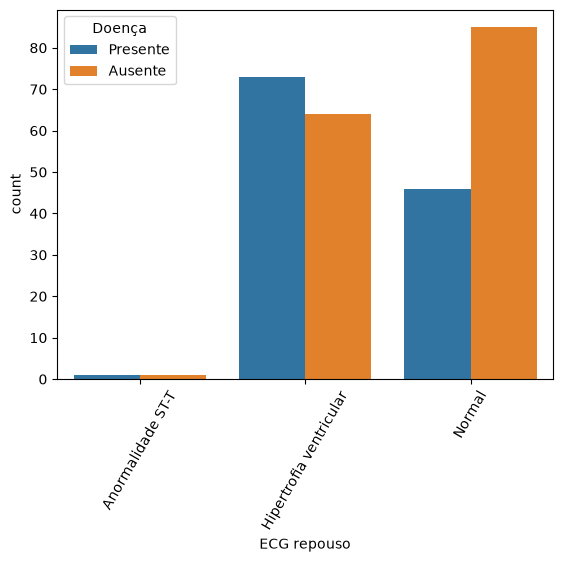

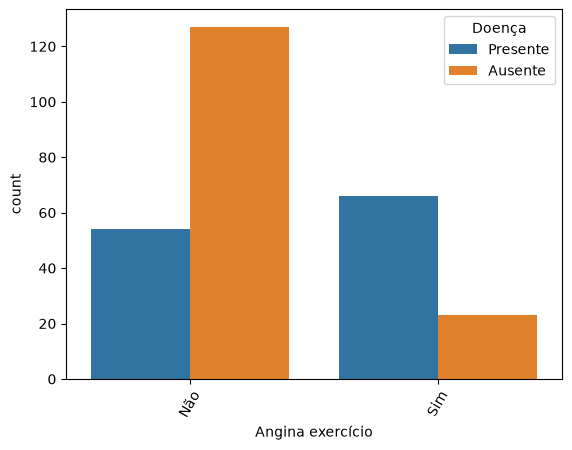

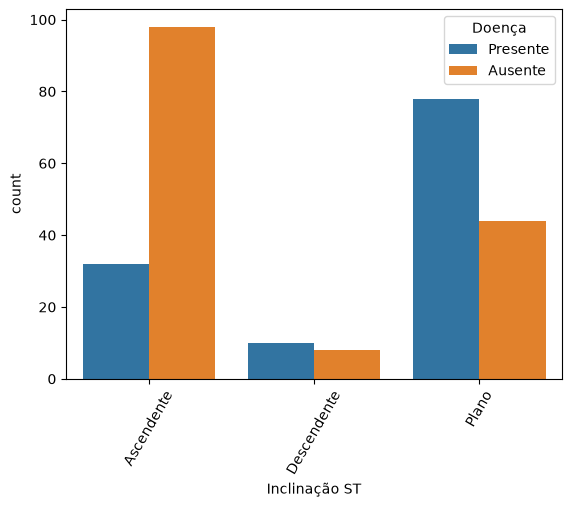

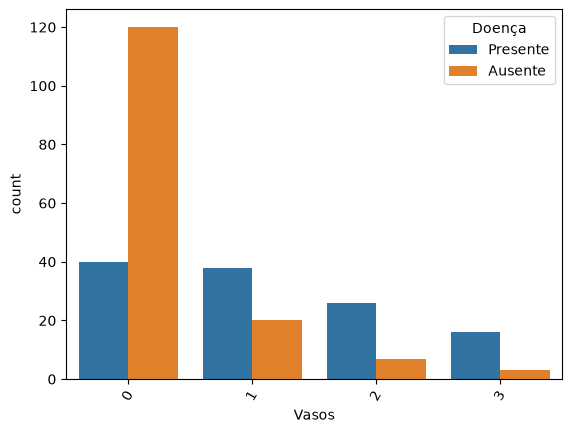

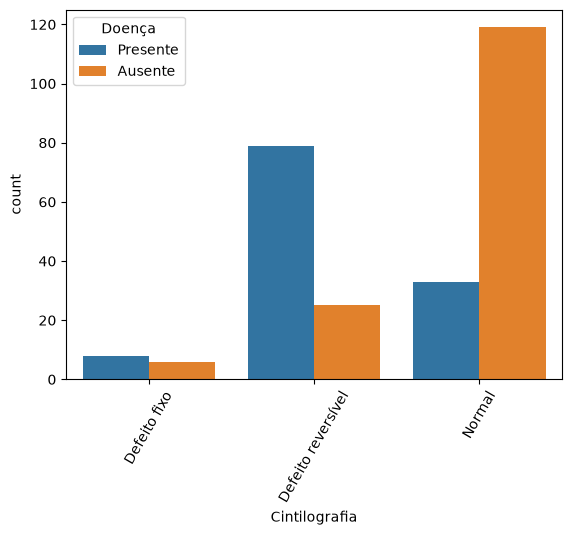

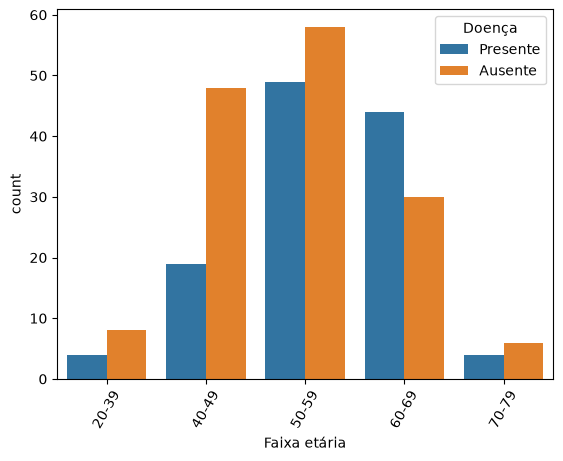

In [29]:
for coluna in categoricas:
    sns.countplot(data=df, x=coluna, hue="Doença", order=sorted(df[coluna].unique()))
    plt.xticks(rotation=60)
    plt.show()

In [30]:
df[numericas].describe()

,Idade,Pressão,Colesterol,Freq. máxima,Oldpeak
count,270.000000,270.000000,270.000000,270.000000,270.00000
mean,54.433333,131.344444,249.659259,149.677778,1.05000
std,9.109067,17.861608,51.686237,23.165717,1.14521
min,29.000000,94.000000,126.000000,71.000000,0.00000
25%,48.000000,120.000000,213.000000,133.000000,0.00000
50%,55.000000,130.000000,245.000000,153.500000,0.80000
75%,61.000000,140.000000,280.000000,166.000000,1.60000
max,77.000000,200.000000,564.000000,202.000000,6.20000


In [31]:
df[numericas].agg(["mean", "median", "std", "var", "skew"])

,Idade,Pressão,Colesterol,Freq. máxima,Oldpeak
mean,54.433333,131.344444,249.659259,149.677778,1.050000
median,55.000000,130.000000,245.000000,153.500000,0.800000
std,9.109067,17.861608,51.686237,23.165717,1.145210
var,82.975093,319.037051,2671.467107,536.650434,1.311506
skew,-0.163615,0.722618,1.183721,-0.527737,1.262893


In [32]:
df[numericas].std() / df[numericas].mean() * 100

Idade            16.734354
Pressão          13.599059
Colesterol       20.702712
Freq. máxima     15.477058
Oldpeak         109.067604
dtype: float64

In [33]:
df.groupby("Doença")[numericas].agg(["mean", "median", "std"])

Idade                      Pressão                    \
               mean median       std        mean median        std   
Doença                                                               
Ausente   52.706667   52.0  9.509830  128.866667  130.0  16.457660   
Presente  56.591667   58.0  8.116273  134.441667  130.0  19.095424   

          Colesterol                   Freq. máxima                    \
                mean median        std         mean median        std   
Doença                                                                  
Ausente   244.213333  236.0  54.019085   158.333333  161.0  19.283357   
Presente  256.466667  255.5  47.969166   138.858333  141.5  23.130719   

           Oldpeak                   
              mean median       std  
Doença                               
Ausente   0.622667    0.2  0.800851  
Presente  1.584167    1.4  1.282067

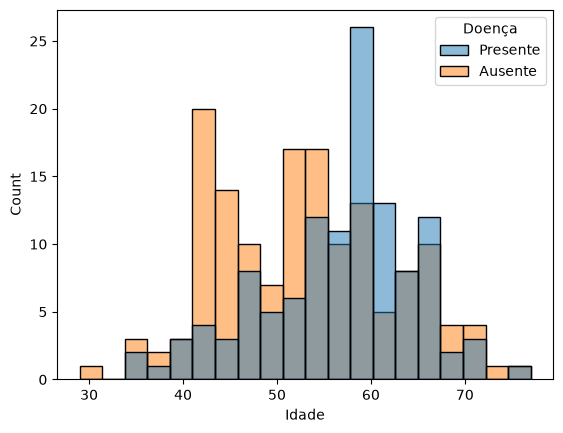

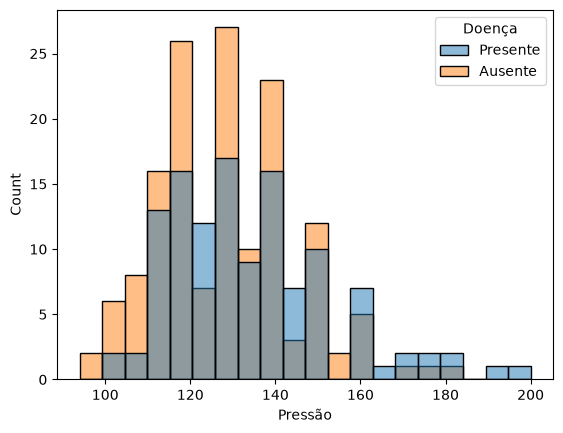

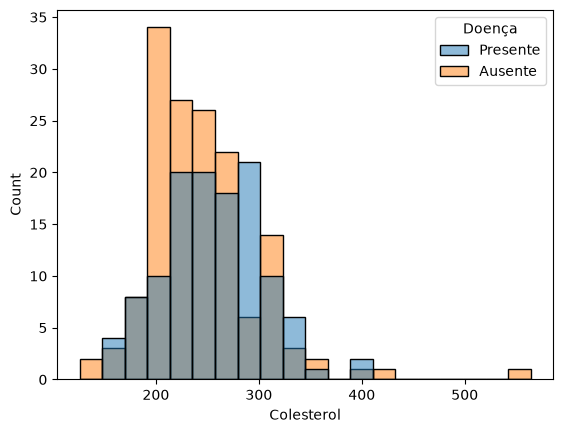

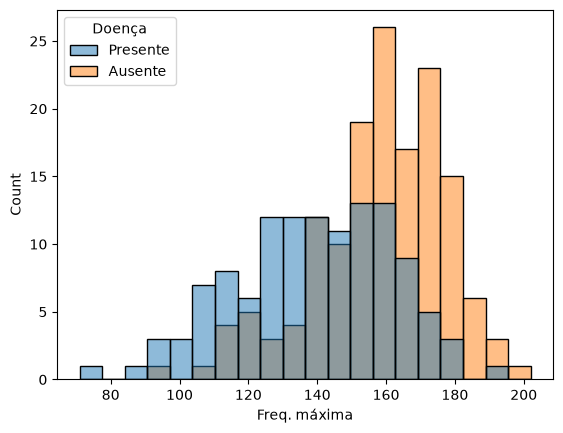

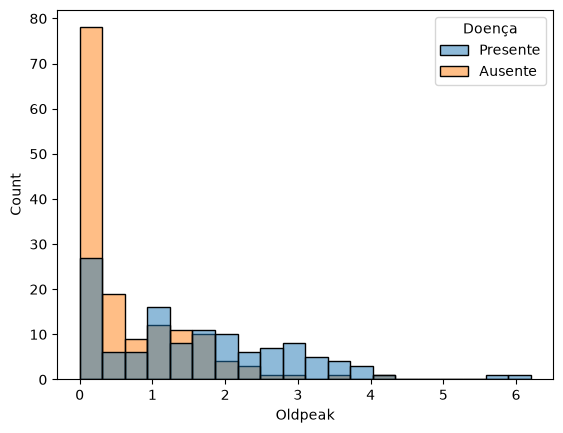

In [34]:
for coluna in numericas:
    sns.histplot(data=df, x=coluna, hue="Doença", bins=20)
    plt.show()

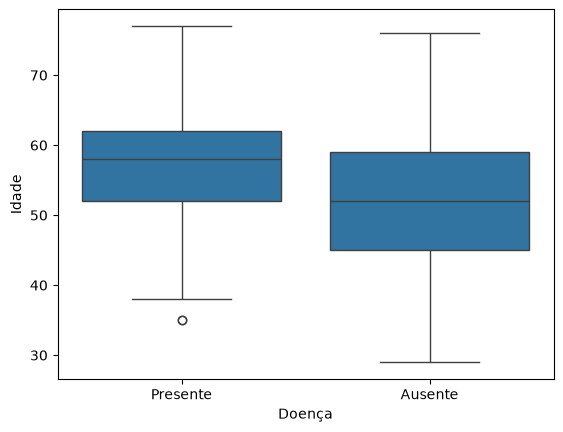

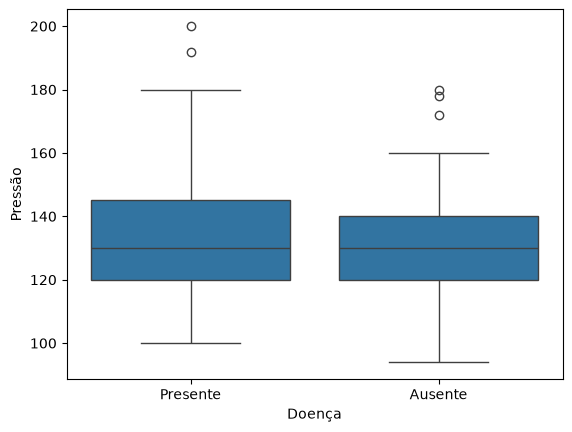

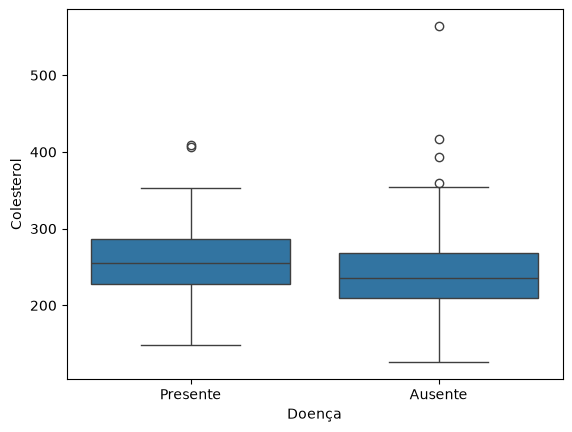

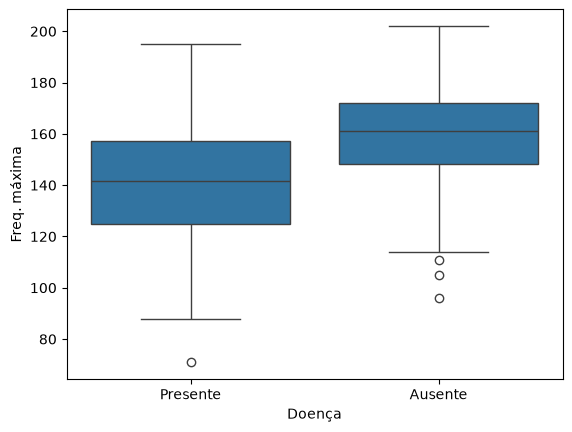

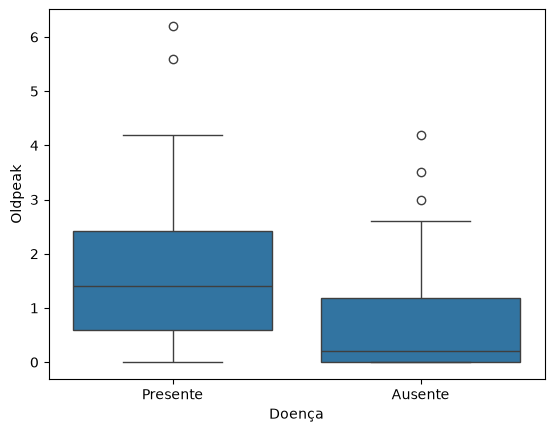

In [35]:
for coluna in numericas:
    sns.boxplot(data=df, x="Doença", y=coluna)
    plt.show()

In [36]:
corr_pearson = df[numericas + ["Doença (0/1)"]].corr()
corr_pearson

,Idade,Pressão,Colesterol,Freq. máxima,Oldpeak,Doença (0/1)
Idade,1.000000,0.273053,0.220056,-0.402215,0.194234,0.212322
Pressão,0.273053,1.000000,0.173019,-0.039136,0.222800,0.155383
Colesterol,0.220056,0.173019,1.000000,-0.018739,0.027709,0.118021
Freq. máxima,-0.402215,-0.039136,-0.018739,1.000000,-0.349045,-0.418514
Oldpeak,0.194234,0.222800,0.027709,-0.349045,1.000000,0.417967
Doença (0/1),0.212322,0.155383,0.118021,-0.418514,0.417967,1.000000


In [37]:
corr_spearman = df[numericas + ["Doença (0/1)"]].corr(method="spearman")
corr_spearman

,Idade,Pressão,Colesterol,Freq. máxima,Oldpeak,Doença (0/1)
Idade,1.000000,0.276844,0.211059,-0.399880,0.257712,0.226405
Pressão,0.276844,1.000000,0.190482,-0.042943,0.182700,0.131147
Colesterol,0.211059,0.190482,1.000000,-0.056473,0.013844,0.162530
Freq. máxima,-0.399880,-0.042943,-0.056473,1.000000,-0.423185,-0.419741
Oldpeak,0.257712,0.182700,0.013844,-0.423185,1.000000,0.405359
Doença (0/1),0.226405,0.131147,0.162530,-0.419741,0.405359,1.000000


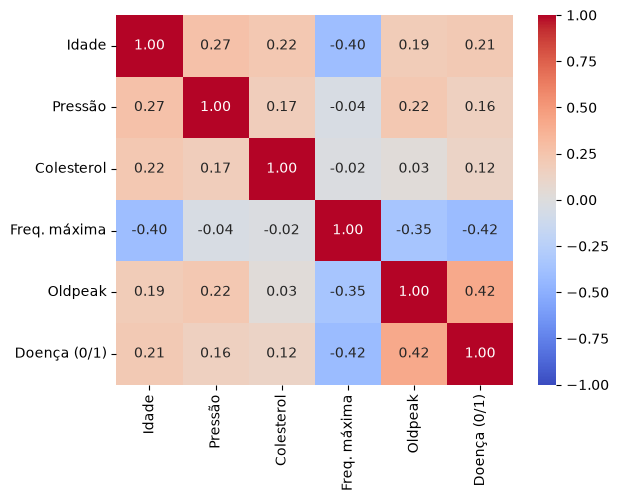

In [38]:
sns.heatmap(corr_pearson, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.show()

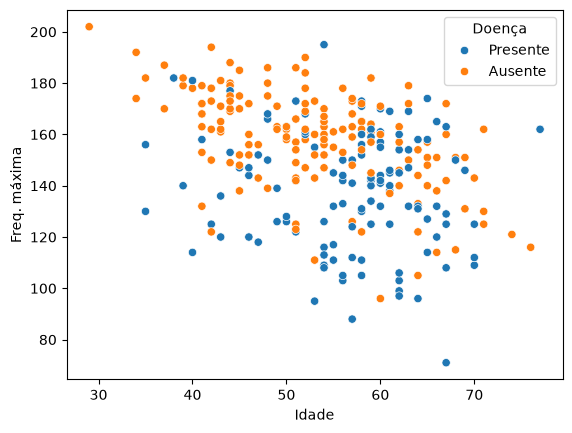

In [39]:
sns.scatterplot(data=df, x="Idade", y="Freq. máxima", hue="Doença")
plt.show()

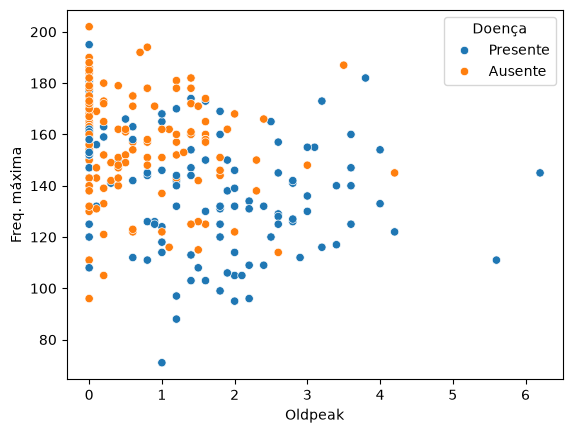

In [40]:
sns.scatterplot(data=df, x="Oldpeak", y="Freq. máxima", hue="Doença")
plt.show()

In [41]:
p_doenca = df["Doença (0/1)"].mean()
p_doenca

np.float64(0.4444444444444444)

In [42]:
df.groupby("Sexo")["Doença (0/1)"].agg(["mean", "count"])

,mean,count
Sexo,,
Feminino,0.229885,87
Masculino,0.546448,183


In [43]:
for coluna in categoricas:
    print(df.groupby(coluna)["Doença (0/1)"].agg(["mean", "count"]))
    print()

               mean  count
Sexo                      
Feminino   0.229885     87
Masculino  0.546448    183

                      mean  count
Tipo de dor                      
Angina atípica    0.166667     42
Angina típica     0.250000     20
Assintomático     0.705426    129
Dor não anginosa  0.215190     79

                   mean  count
Glicemia alta                 
Não            0.447826    230
Sim            0.425000     40

                             mean  count
ECG repouso                             
Anormalidade ST-T        0.500000      2
Hipertrofia ventricular  0.532847    137
Normal                   0.351145    131

                      mean  count
Angina exercício                 
Não               0.298343    181
Sim               0.741573     89

                   mean  count
Inclinação ST                 
Ascendente     0.246154    130
Descendente    0.555556     18
Plano          0.639344    122

           mean  count
Vasos                 
0      0.250000 

In [44]:
pd.crosstab(df["Tipo de dor"], df["Doença"], normalize="index")

Doença,Ausente,Presente
Tipo de dor,,
Angina atípica,0.833333,0.166667
Angina típica,0.750000,0.250000
Assintomático,0.294574,0.705426
Dor não anginosa,0.784810,0.215190


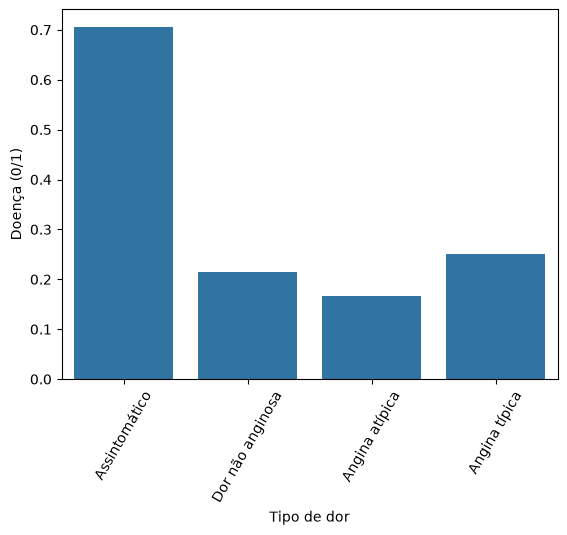

In [45]:
sns.barplot(data=df, x="Tipo de dor", y="Doença (0/1)", errorbar=None)
plt.xticks(rotation=60)
plt.show()

In [46]:
p_masculino = (df["Sexo"] == "Masculino").mean()
p_masculino

np.float64(0.6777777777777778)

In [47]:
com_doenca = df[df["Doença"] == "Presente"]
p_masculino_dado_doenca = (com_doenca["Sexo"] == "Masculino").mean()
p_masculino_dado_doenca

np.float64(0.8333333333333334)

In [48]:
p_doenca_dado_masculino = p_masculino_dado_doenca * p_doenca / p_masculino
p_doenca_dado_masculino

np.float64(0.5464480874316939)

In [49]:
df[df["Sexo"] == "Masculino"]["Doença (0/1)"].mean()

np.float64(0.546448087431694)

In [50]:
p_conjunta = ((df["Sexo"] == "Masculino") & (df["Doença"] == "Presente")).mean()
p_conjunta

np.float64(0.37037037037037035)

In [51]:
p_masculino * p_doenca

np.float64(0.30123456790123454)

In [52]:
filtro = (df["Idade"] >= 50) & (df["Sexo"] == "Feminino")
df[filtro]

,Idade,Sexo,Tipo de dor,Pressão,Colesterol,Glicemia alta,ECG repouso,Freq. máxima,Angina exercício,Oldpeak,Inclinação ST,Vasos,Cintilografia,Doença,Doença (0/1),Faixa etária,Atípico
1,67,Feminino,Dor não anginosa,115,564,Não,Hipertrofia ventricular,160,Não,1.6,Plano,0,Defeito reversível,Ausente,0,60-69,True
4,74,Feminino,Angina atípica,120,269,Não,Hipertrofia ventricular,121,Sim,0.2,Ascendente,1,Normal,Ausente,0,70-79,False
9,63,Feminino,Assintomático,150,407,Não,Hipertrofia ventricular,154,Não,4.0,Plano,3,Defeito reversível,Presente,1,60-69,True
14,57,Feminino,Assintomático,128,303,Não,Hipertrofia ventricular,159,Não,0.0,Ascendente,1,Normal,Ausente,0,50-59,False
15,71,Feminino,Assintomático,112,149,Não,Normal,125,Não,1.6,Plano,0,Normal,Ausente,0,70-79,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
244,51,Feminino,Dor não anginosa,140,308,Não,Hipertrofia ventricular,142,Não,1.5,Ascendente,1,Normal,Ausente,0,50-59,False
247,65,Feminino,Dor não anginosa,155,269,Não,Normal,148,Não,0.8,Ascendente,0,Normal,Ausente,0,60-69,False
255,71,Feminino,Angina atípica,160,302,Não,Normal,162,Não,0.4,Ascendente,2,Normal,Ausente,0,70-79,False
260,58,Feminino,Dor não anginosa,120,340,Não,Normal,172,Não,0.0,Ascendente,0,Normal,Ausente,0,50-59,False


In [53]:
df[filtro]["Doença (0/1)"].mean()

np.float64(0.296875)

In [54]:
filtro = (df["Colesterol"] > 240) & (~df["Atípico"])
df[filtro]

,Idade,Sexo,Tipo de dor,Pressão,Colesterol,Glicemia alta,ECG repouso,Freq. máxima,Angina exercício,Oldpeak,Inclinação ST,Vasos,Cintilografia,Doença,Doença (0/1),Faixa etária,Atípico
0,70,Masculino,Assintomático,130,322,Não,Hipertrofia ventricular,109,Não,2.4,Plano,3,Normal,Presente,1,70-79,False
2,57,Masculino,Angina atípica,124,261,Não,Normal,141,Não,0.3,Ascendente,0,Defeito reversível,Presente,1,50-59,False
3,64,Masculino,Assintomático,128,263,Não,Normal,105,Sim,0.2,Plano,1,Defeito reversível,Ausente,0,60-69,False
4,74,Feminino,Angina atípica,120,269,Não,Hipertrofia ventricular,121,Sim,0.2,Ascendente,1,Normal,Ausente,0,70-79,False
6,56,Masculino,Dor não anginosa,130,256,Sim,Hipertrofia ventricular,142,Sim,0.6,Plano,1,Defeito fixo,Presente,1,50-59,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
262,58,Masculino,Angina atípica,120,284,Não,Hipertrofia ventricular,160,Não,1.8,Plano,0,Normal,Presente,1,50-59,False
263,49,Masculino,Angina atípica,130,266,Não,Normal,171,Não,0.6,Ascendente,0,Normal,Ausente,0,40-49,False
266,44,Masculino,Angina atípica,120,263,Não,Normal,173,Não,0.0,Ascendente,0,Defeito reversível,Ausente,0,40-49,False
267,56,Feminino,Angina atípica,140,294,Não,Hipertrofia ventricular,153,Não,1.3,Plano,0,Normal,Ausente,0,50-59,False


In [55]:
df[filtro]["Doença (0/1)"].mean()

np.float64(0.5114503816793893)